In [1]:
## titanic project

from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np

df = pd.read_csv('titanic.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df.head()

Saving titanic.csv to titanic.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
#data cleaning
#Remove the cabin

df.drop('Cabin', axis=1, inplace=True)

In [4]:
#the Median age of the passengers.


df['Age'] = df['Age'].fillna(df['Age'].median())

In [5]:
#mode

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [6]:
#feature Renaming

df.rename(columns={
    'Pclass': 'Ticket_Class',
    'SibSp': 'Siblings_Spouses',
    'Parch': 'Parents_Children'
}, inplace=True)

In [7]:
#calculate the no. of passengers traveling without any family members

df[df['Fare'] > 100]

,PassengerId,Survived,Ticket_Class,Name,Sex,Age,Siblings_Spouses,Parents_Children,Ticket,Fare,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.00,3,2,19950,263.0000,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,28.00,1,0,PC 17569,146.5208,C
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.00,3,2,19950,263.0000,S
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.00,0,1,PC 17558,247.5208,C
195,196,1,1,"Lurette, Miss. Elise",female,58.00,0,0,PC 17569,146.5208,C
215,216,1,1,"Newell, Miss. Madeleine",female,31.00,1,0,35273,113.2750,C
258,259,1,1,"Ward, Miss. Anna",female,35.00,0,0,PC 17755,512.3292,C
268,269,1,1,"Graham, Mrs. William Thompson (Edith Junkins)",female,58.00,0,1,PC 17582,153.4625,S
269,270,1,1,"Bissette, Miss. Amelia",female,35.00,0,0,PC 17760,135.6333,S
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,S


In [8]:
# creating an age group column categorizing passengers

df[(df['Sex'] == 'female') & (df['Age'] < 18)]

,PassengerId,Survived,Ticket_Class,Name,Sex,Age,Siblings_Spouses,Parents_Children,Ticket,Fare,Embarked
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.00,1,0,237736,30.0708,C
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.00,1,1,PP 9549,16.7000,S
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.00,0,0,350406,7.8542,S
22,23,1,3,"McGowan, Miss. Anna ""Annie""",female,15.00,0,0,330923,8.0292,Q
24,25,0,3,"Palsson, Miss. Torborg Danira",female,8.00,3,1,349909,21.0750,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.00,1,0,2651,11.2417,C
43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.00,1,2,SC/Paris 2123,41.5792,C
58,59,1,2,"West, Miss. Constance Mirium",female,5.00,1,2,C.A. 34651,27.7500,S
68,69,1,3,"Andersson, Miss. Erna Alexandra",female,17.00,4,2,3101281,7.9250,S
71,72,0,3,"Goodwin, Miss. Lillian Amy",female,16.00,5,2,CA 2144,46.9000,S


In [12]:
df.sort_values(by='Fare', ascending=False)

,PassengerId,Survived,Ticket_Class,Name,Sex,Age,Siblings_Spouses,Parents_Children,Ticket,Fare,Embarked
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.00,0,0,PC 17755,512.3292,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.00,0,1,PC 17755,512.3292,C
258,259,1,1,"Ward, Miss. Anna",female,35.00,0,0,PC 17755,512.3292,C
438,439,0,1,"Fortune, Mr. Mark",male,64.00,1,4,19950,263.0000,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.00,3,2,19950,263.0000,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.00,3,2,19950,263.0000,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.00,3,2,19950,263.0000,S
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.00,2,2,PC 17608,262.3750,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.00,2,2,PC 17608,262.3750,C
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.00,0,1,PC 17558,247.5208,C


In [11]:
#Sort by Fare (Descending)

df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [10]:
#Avg Fare by Ticket Class
df.groupby('Ticket_Class')['Fare'].mean()

,Fare
Ticket_Class,
1,84.154687
2,20.662183
3,13.675550


In [9]:

#Port with Highest Passengers

df['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


In [36]:
df[(df['SibSp'] == 0) & (df['Parch'] == 0)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Adult
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Adult
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,Adult
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S,Adult
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S,Child
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S,Adult
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S,Adult
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C,Adult


In [31]:
age_group = []

for age in df['Age']:
    if age < 18:
        age_group.append('Child')
    else:
        age_group.append('Adult')

df['Age_Group'] = age_group

In [38]:
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

In [35]:
avg_fare = df['Fare'].mean()
df[df['Fare'] > avg_fare]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.2833,C85,C,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.1000,C123,S,Adult
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.00,0,0,17463,51.8625,E46,S,Adult
23,24,1,1,"Sloper, Mr. William Thompson",male,28.00,0,0,113788,35.5000,A6,S,Adult
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.00,3,2,19950,263.0000,C23 C25 C27,S,Adult
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C,Adult
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.00,1,0,PC 17604,82.1708,NaN,C,Adult
35,36,0,1,"Holverson, Mr. Alexander Oskar",male,42.00,1,0,113789,52.0000,NaN,S,Adult
43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.00,1,2,SC/Paris 2123,41.5792,NaN,C,Child
50,51,0,3,"Panula, Master. Juha Niilo",male,7.00,4,1,3101295,39.6875,NaN,S,Child


In [30]:
# survival gap analysis

survival = df.groupby('Pclass')['Survived'].mean()

gap = (survival[1] - survival[3]) * 100
print(gap)

38.72671041713812


In [15]:
df.info()
df.isnull().sum()
df.describe()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


np.int64(0)

In [14]:
df.to_csv('titanic.csv',index=False)

from google.colab import files
files.download('titanic.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:

from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np

df = pd.read_csv('titanic.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df.head()

Saving titanic.csv to titanic (1).csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


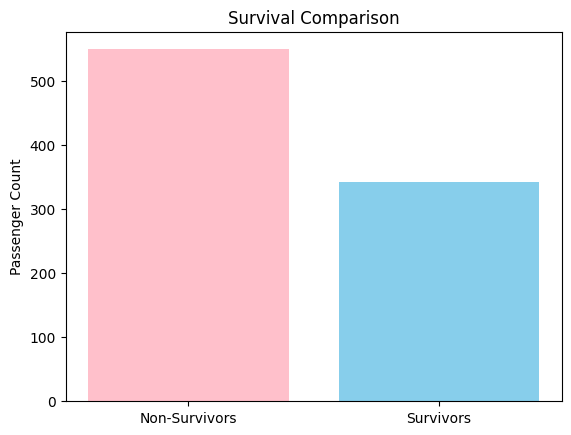

In [17]:
# task 1
import matplotlib.pyplot as plt

survival_counts = df['Survived'].value_counts()

plt.bar(['Non-Survivors','Survivors'],
        survival_counts.values,
        color=['pink','skyblue'])

plt.title("Survival Comparison")
plt.ylabel("Passenger Count")
plt.show()

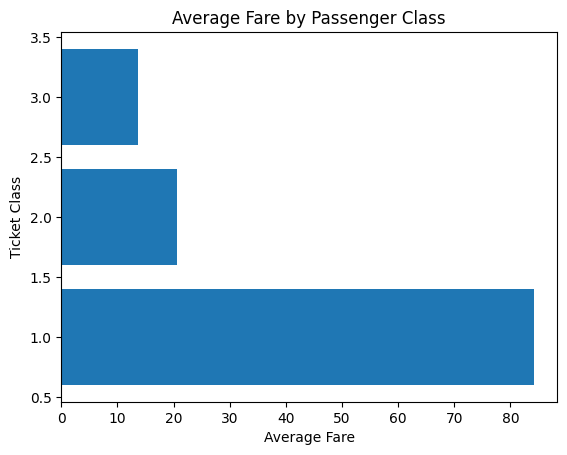

In [20]:
##task2

avg_fare = df.groupby('Pclass')['Fare'].mean()

plt.barh(avg_fare.index, avg_fare.values)

plt.title("Average Fare by Passenger Class")
plt.xlabel("Average Fare")
plt.ylabel("Ticket Class")
plt.show()

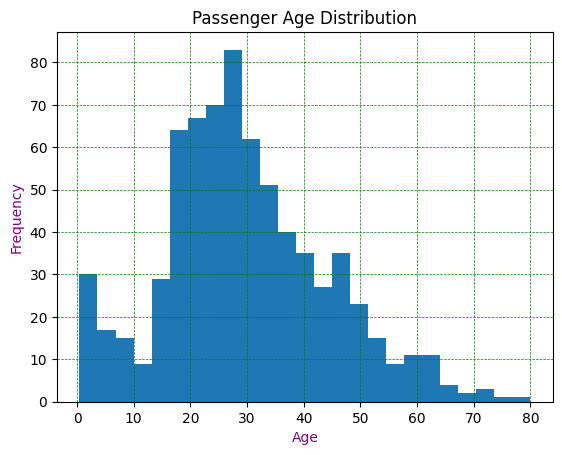

In [21]:
##task3

plt.hist(df['Age'], bins=25)

plt.title("Passenger Age Distribution")
plt.xlabel("Age", color='purple')
plt.ylabel("Frequency", color='purple')

plt.grid(True)
plt.grid(color='green', linestyle='--', linewidth=0.5)

plt.show()

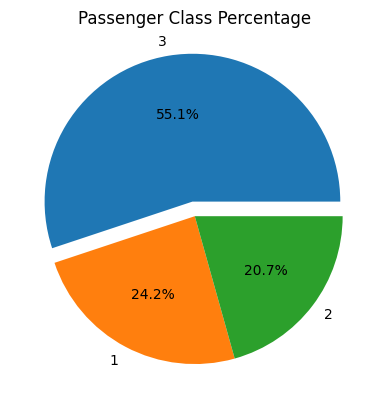

In [23]:
## task 4
class_counts = df['Pclass'].value_counts()

plt.pie(class_counts,
        labels=class_counts.index,
        autopct='%1.1f%%',
        explode=[0.1,0,0])

plt.title("Passenger Class Percentage")
plt.show()

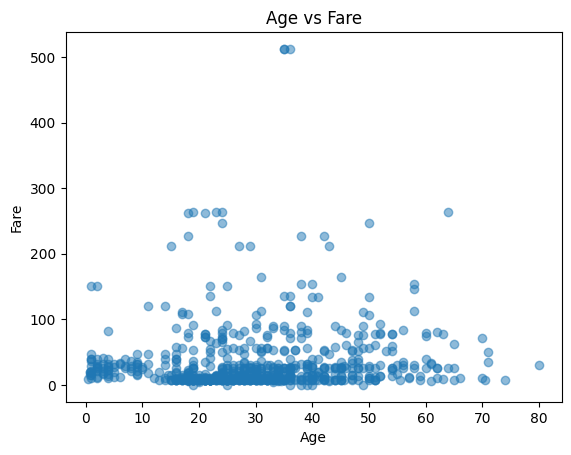

In [24]:
##task 5

plt.scatter(df['Age'],
            df['Fare'],
            marker='o',
            alpha=0.5)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare")
plt.show()

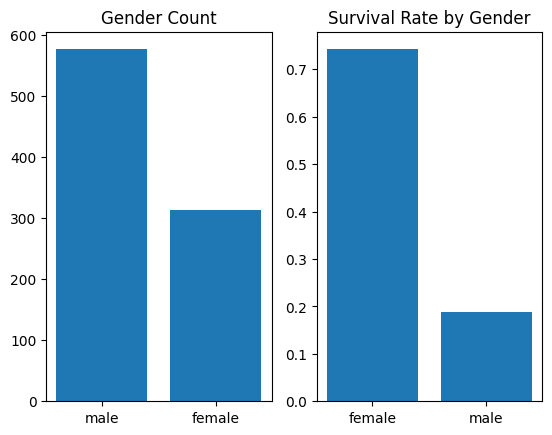

In [25]:
##task6

fig, ax = plt.subplots(1,2)

gender_counts = df['Sex'].value_counts()

ax[0].bar(gender_counts.index,
          gender_counts.values)

ax[0].set_title("Gender Count")


survival_rate = df.groupby('Sex')['Survived'].mean()

ax[1].bar(survival_rate.index,
          survival_rate.values)

ax[1].set_title("Survival Rate by Gender")

plt.show()

In [ ]:
## task 7
fare_sorted = df['Fare'].sort_values().reset_index(drop=True)

plt.plot(fare_sorted)

plt.fill_between(range(len(fare_sorted)),
                 fare_sorted,
                 alpha=0.3)

plt.title("Fare Trend")
plt.ylabel("Fare")

plt.show()


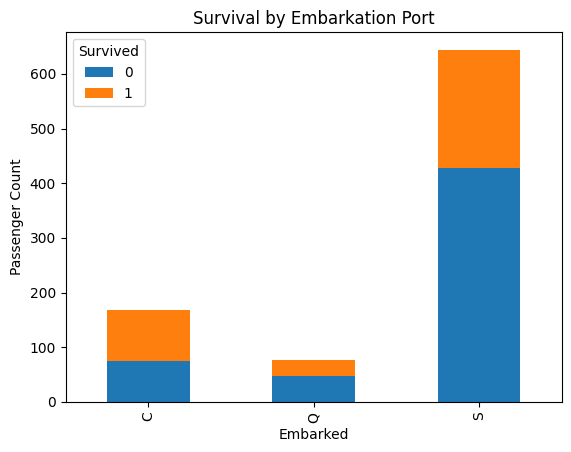

In [26]:
## task 8

embark_survival = df.groupby(['Embarked','Survived']).size().unstack()

embark_survival.plot(kind='bar', stacked=True)

plt.title("Survival by Embarkation Port")
plt.ylabel("Passenger Count")

plt.show()

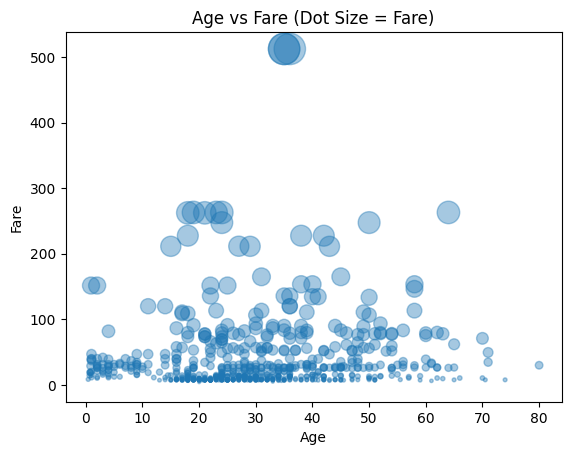

In [27]:
#task 9

plt.scatter(df['Age'],
            df['Fare'],
            s=df['Fare'],
            alpha=0.4)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare (Dot Size = Fare)")

plt.show()

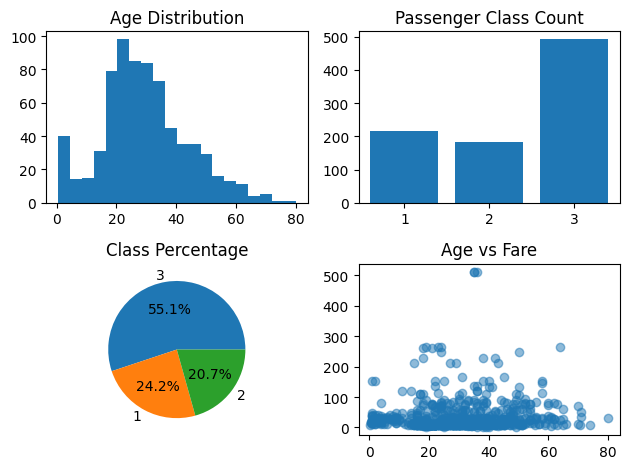

In [29]:
##task 10

fig, ax = plt.subplots(2,2)

# Histogram
ax[0,0].hist(df['Age'], bins=20)
ax[0,0].set_title("Age Distribution")

# Bar chart
class_counts = df['Pclass'].value_counts()
ax[0,1].bar(class_counts.index, class_counts.values)
ax[0,1].set_title("Passenger Class Count")

# Pie chart
ax[1,0].pie(class_counts,
            labels=class_counts.index,
            autopct='%1.1f%%')

ax[1,0].set_title("Class Percentage")

# Scatter
ax[1,1].scatter(df['Age'], df['Fare'], alpha=0.5)
ax[1,1].set_title("Age vs Fare")

plt.tight_layout()
plt.show()